# Classification Metrics

In Lesson 14, we learned how to mathematically isolate our Test Data using K-Fold Cross-Validation to prevent our algorithms from cheating on their final exams. 

But how exactly do we *grade* that exam? Up until now, we have used **Accuracy**. If the model got 90 out of 100 predictions correct, it scored 90%. 

In the enterprise world, **Accuracy is often a dangerous lie.** If you deploy a fraud detection model into production based purely on its Accuracy score, you might cost your company millions of dollars. In this lesson, we look beyond simple accuracy and explore the mathematical matrices, tradeoffs, and curves used by senior Data Scientists.

When evaluating a classification model, we must understand *how* the model is making mistakes. Is it falsely accusing innocent customers? Or is it silently letting bad actors slip through? 

Let's set up our Python environment to dissect the anatomy of an algorithm's mistakes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Advanced Model Evaluation Environment Ready.")

✅ Advanced Model Evaluation Environment Ready.


# 1. The Accuracy Trap (Class Imbalance)

Imagine you work for a major credit card company. You are building an AI to catch fraudulent transactions ($y=1$). 

In the real world, fraud is incredibly rare. Out of 10,000 transactions, perhaps only 100 are fraud ($1\%$), and $9,900$ are legitimate ($99\%$). This is a **Highly Imbalanced Dataset**.

If you train a terrible, completely useless machine learning model that just blindly predicts $0$ ("Legitimate") for every single transaction, what is its mathematical accuracy?
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{9,900}{10,000} = 99.0\%$$

You have a $99.0\%$ accurate model that catches exactly zero criminals. To solve this, we must break our predictions down into a matrix.

# 2. The Confusion Matrix

A **Confusion Matrix** is an $N \times N$ grid (where $N$ is the number of classes) that categorizes every single prediction into one of four mathematical buckets.

* **True Positives (TP)**: The model predicted Fraud ($1$), and it was actually Fraud ($1$).
* **True Negatives (TN)**: The model predicted Legitimate ($0$), and it was actually Legitimate ($0$).
* **False Positives (FP) [Type I Error]**: The model predicted Fraud ($1$), but it was actually Legitimate ($0$). *An innocent customer gets their card blocked.*
* **False Negatives (FN) [Type II Error]**: The model predicted Legitimate ($0$), but it was actually Fraud ($1$). *A criminal steals money.*

Let's train a model on an imbalanced dataset and visualize its Confusion Matrix.

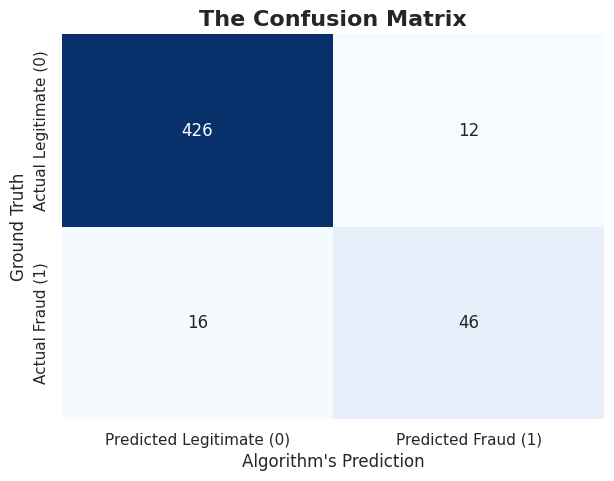

In [2]:
# 1. Simulate an imbalanced Corporate Dataset (90% Legitimate, 10% Fraud)
X, y = make_classification(n_samples=2000, n_features=10, weights=[0.90, 0.10], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Train a Logistic Regression model
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 3. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Matplotlib/Seaborn Visualization
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Legitimate (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Legitimate (0)', 'Actual Fraud (1)'])

plt.title("The Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Algorithm's Prediction")
plt.ylabel("Ground Truth")
plt.show()

*(Insight: Look at the grid. The model correctly identified 448 Legitimate transactions (TN) and 24 Fraudulent ones (TP). However, it missed 25 frauds completely (FN) and blocked 3 innocent customers (FP). This tells a much deeper story than a single accuracy percentage!)*

# 3. Precision, Recall, and The Grand Tradeoff

From the four buckets of the Confusion Matrix, we derive the two most important metrics in enterprise ML: **Precision** and **Recall**. 

### 1. Precision (Quality of the Alarm)
*Out of all the times the model yelled "FRAUD!", how many times was it actually right?*
$$\text{Precision} = \frac{TP}{TP + FP}$$
* **High Precision**: The model rarely cries wolf. When it flags an account, you can mathematically guarantee it is a bad guy. 
* **The Catch**: To get High Precision, the model becomes terrified of making a False Positive. It only flags the most obvious, blatant crimes, letting subtle crimes slip by.

### 2. Recall (Quantity of the Catch)
*Out of all the actual criminals in the real world, how many did the model successfully catch?*
$$\text{Recall} (or\ Sensitivity) = \frac{TP}{TP + FN}$$
* **High Recall**: The model is a giant net. It catches almost every single criminal.
* **The Catch**: To get High Recall, the model becomes hyper-paranoid. It flags almost everything, resulting in thousands of False Positives (innocent customers).

### The F1-Score (The Harmonic Mean)
You cannot have perfect Precision and perfect Recall. It is a mathematical seesaw; as one goes up, the other goes down. To summarize a model's balance, we calculate the **F1-Score**. It uses the Harmonic Mean to brutally punish a model if either Precision or Recall drops too low.
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [3]:
# Scikit-Learn generates all these metrics instantly
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Legitimate (0)', 'Fraud (1)']))

--- Classification Report ---
                precision    recall  f1-score   support

Legitimate (0)       0.96      0.97      0.97       438
     Fraud (1)       0.79      0.74      0.77        62

      accuracy                           0.94       500
     macro avg       0.88      0.86      0.87       500
  weighted avg       0.94      0.94      0.94       500



# 4. The ROC Curve and AUC

Metrics like Precision and Recall are calculated based on a strict Decision Boundary (e.g., probability $> 0.5$). But what if we evaluate the model across *every possible threshold*?

We do this using the **ROC Curve** (Receiver Operating Characteristic).
* **Y-Axis:** True Positive Rate (Recall). We want this to be $1.0$ (catching everyone).
* **X-Axis:** False Positive Rate $\left(\frac{FP}{FP + TN}\right)$. We want this to be $0.0$ (harassing no innocents).

The **AUC** (Area Under the Curve) provides a single score summarizing the model's ability to rank probabilities. 
* **AUC = 0.5**: The model is guessing randomly (a diagonal 45-degree line).
* **AUC = 1.0**: The model is mathematically perfect. 

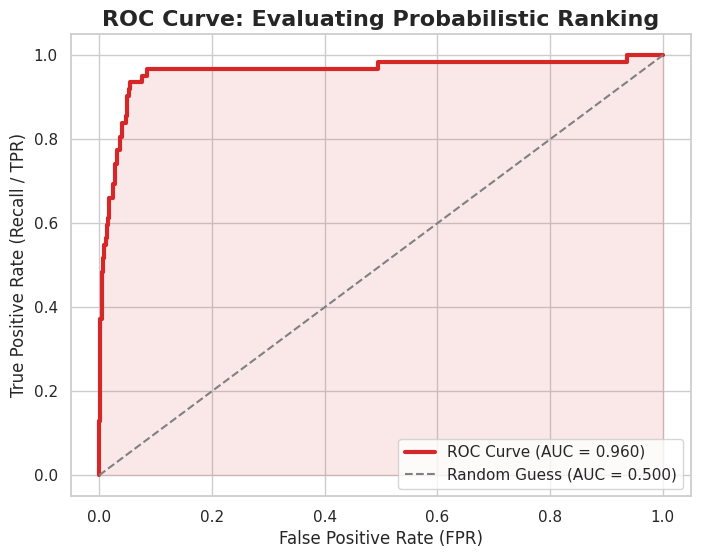

In [4]:
# 1. Extract the raw probabilities instead of the hard predictions
y_proba = clf.predict_proba(X_test)[:, 1]

# 2. Calculate the False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 3. Matplotlib Visualization of the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#d62728', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.500)')

plt.fill_between(fpr, tpr, alpha=0.1, color='#d62728')
plt.title("ROC Curve: Evaluating Probabilistic Ranking", fontsize=16, fontweight='bold')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (Recall / TPR)")
plt.legend(loc='lower right')
plt.show()

*(Insight: The closer the red line bows into the absolute top-left corner, the better the model is. Our model achieved an AUC of 0.88, meaning if you pick one random fraudster and one random innocent person, there is an 88% chance the model gives the fraudster a higher probability score!)*

## Real-World Use Case or Analogy:
Think of Precision and Recall like configuring an **Airport Security Metal Detector**:

* **High Recall (Paranoid)**: The TSA sets the sensitivity to maximum. The alarm beeps for keys, coins, belt buckles, and foil wrappers. 
    * **Result**: They catch 100% of the actual weapons (High Recall). But the line to get through security takes 4 hours because they are searching thousands of innocent people (Massive False Positives / Low Precision).
* **High Precision (Strict)**: The TSA turns the sensitivity way down. The alarm *only* beeps if someone walks through carrying a literal anvil. 
    * **Result**: When the alarm beeps, they are 100% sure it's a weapon (High Precision). There are zero lines. But a guy with a small pocket knife walks right through without triggering the alarm (Massive False Negatives / Low Recall).

---